In [25]:
"""
Introduction to Continuous GFlowNets with Beta Distributions
=============================================================

This notebook demonstrates how to train a GFlowNet on a continuous 2D
environment (the "Box") where forward/backward steps are sampled from
per-dimension Beta mixture distributions.

Based on: "A theory of continuous generative flow networks"
          (https://arxiv.org/abs/2301.12594)
"""

'\nIntroduction to Continuous GFlowNets with Beta Distributions\n=============================================================\n\nThis notebook demonstrates how to train a GFlowNet on a continuous 2D\nenvironment (the "Box") where forward/backward steps are sampled from\nper-dimension Beta mixture distributions.\n\nBased on: "A theory of continuous generative flow networks"\n          (https://arxiv.org/abs/2301.12594)\n'

# Continuous GFlowNets with Beta Distributions

In discrete GFlowNets, the forward policy outputs a categorical distribution over a finite action set. In **continuous GFlowNets**, the forward policy instead predicts the *parameters of a continuous distribution*, and actions are sampled from that distribution.

Here we use the **Box** environment: a 2D unit square $[0, 1]^2$ where:
- The agent starts at the origin $(0, 0)$.
- At each step, it samples a per-dimension increment from a **mixture of Beta distributions**, adding it to the current position.
- It can choose to **exit** (terminate) at any step, or is forced to exit when it hits the boundary.
- The reward has four peaks near the corners of the square.

The key objects are:
1. **Environment** (`Box`): defines the state space, transitions, and reward.
2. **Policy MLPs** (`BoxCartesianPFMLP`, `BoxCartesianPBMLP`): neural networks that predict Beta mixture parameters.
3. **Estimators** (`BoxCartesianPFEstimator`, `BoxCartesianPBEstimator`): wrap the MLPs and produce probability distributions over actions.
4. **GFlowNet** (`TBGFlowNet`): computes the Trajectory Balance loss.
5. **Sampler**: rolls out trajectories using the forward policy.

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from numpy.typing import NDArray
from scipy.special import logsumexp
from sklearn.neighbors import KernelDensity
from tqdm import tqdm, trange

from gfn.gflownet import TBGFlowNet
from gfn.gym import Box
from gfn.gym.helpers.box_utils import (
    BoxCartesianPBEstimator,
    BoxCartesianPBMLP,
    BoxCartesianPFEstimator,
    BoxCartesianPFMLP,
)
from gfn.samplers import Sampler
from gfn.utils.common import set_seed

## 1. The Box Environment

The `Box` environment lives in $[0, 1]^2$. The reward function has peaks near the four corners — specifically where both coordinates are far from 0.5:

$$R(x) = R_0 + R_1 \cdot \mathbb{1}[|x_i - 0.5| \in (0.25, 0.5)] + R_2 \cdot \mathbb{1}[|x_i - 0.5| \in (0.3, 0.4)]$$

with $R_0 = 0.1$, $R_1 = 0.5$, $R_2 = 2.0$. This creates four rectangular high-reward regions near the corners.

The `delta` parameter controls the maximum step size: each per-dimension increment is in $[0, \delta]$. Smaller delta means longer trajectories and a harder learning problem.

In [27]:
seed = 4444
set_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

delta = 0.25  # Larger delta = fewer steps = faster training for a demo.
env = Box(delta=delta, epsilon=1e-10, device=device)

print(f"State shape:  {env.state_shape}")
print(f"Action shape: {env.action_shape}")
print(f"Delta (max step size per dim): {env.delta}")
print(f"s0: {env.s0}")
print(f"True log Z: {env.log_partition():.4f}")

State shape:  (2,)
Action shape: (2,)
Delta (max step size per dim): 0.25
s0: tensor([0., 0.])
True log Z: -1.1874


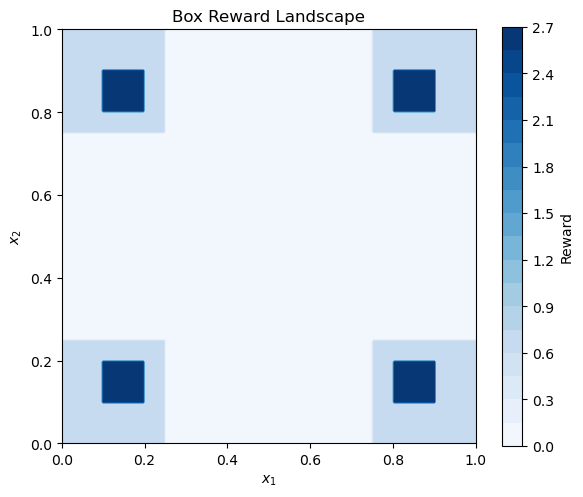

In [28]:
# Visualize the reward landscape.
x = np.linspace(0, 1, 200)
y = np.linspace(0, 1, 200)
X, Y = np.meshgrid(x, y)
grid = torch.tensor(np.stack([X.flatten(), Y.flatten()], axis=1), dtype=torch.float32)
rewards = env.reward(env.States(grid.to(device))).cpu().numpy().reshape(X.shape)

fig, ax = plt.subplots(figsize=(6, 5))
c = ax.contourf(X, Y, rewards, levels=20, cmap="Blues")
plt.colorbar(c, ax=ax, label="Reward")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Box Reward Landscape")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 2. Forward and Backward Policies (Beta Mixtures)

Each policy MLP takes the current 2D state and outputs parameters for a **mixture of Beta distributions** — one mixture per spatial dimension. The Beta distribution is ideal here because it's naturally bounded on $[0, 1]$, which we scale to $[0, \delta]$.

For each dimension, the MLP predicts:
- **Mixture weights** (logits over $K$ components)
- **Concentration parameters** $(\alpha_k, \beta_k)$ for each component

The forward policy also predicts an **exit probability** (Bernoulli logit) — the probability of terminating at the current state.

The `tied` option shares the trunk (hidden layers) between PF and PB, with only the output heads being separate.

In [29]:
hidden_dim = 128
n_hidden = 3
n_components = 2  # Number of Beta mixture components per dimension.
tied = True  # Share trunk between PF and PB.

pf_module = BoxCartesianPFMLP(
    hidden_dim=hidden_dim,
    n_hidden_layers=n_hidden,
    n_components=n_components,
)
pb_module = BoxCartesianPBMLP(
    hidden_dim=hidden_dim,
    n_hidden_layers=n_hidden,
    n_components=n_components,
    trunk=pf_module.trunk if tied else None,  # Shared trunk.
)

pf_estimator = BoxCartesianPFEstimator(
    env, pf_module, n_components=n_components,
    min_concentration=0.1, max_concentration=100.0,
)
pb_estimator = BoxCartesianPBEstimator(
    env, pb_module, n_components=n_components,
    min_concentration=0.1, max_concentration=100.0,
)

print(f"PF parameters: {sum(p.numel() for p in pf_module.parameters()):,}")
print(f"PB parameters: {sum(p.numel() for p in pb_module.parameters()):,}")
print(f"  (PB trunk is {'shared' if tied else 'independent'})")

PF parameters: 35,085
PB parameters: 35,085
  (PB trunk is shared)


## 3. GFlowNet and Optimizer

We use **Trajectory Balance (TB)** which learns a scalar $\log Z$ alongside the policies. TB requires that for every complete trajectory $\tau = (s_0 \to s_1 \to \cdots \to s_n)$:

$$\log Z + \sum_t \log P_F(s_{t+1} | s_t) = \log R(s_n) + \sum_t \log P_B(s_t | s_{t+1})$$

The loss is the squared difference of the two sides, averaged over sampled trajectories.

In [30]:
gflownet = TBGFlowNet(pf=pf_estimator, pb=pb_estimator).to(device)
sampler = Sampler(estimator=pf_estimator)

lr = 1e-4
lr_Z = 1e-2

optimizer = torch.optim.Adam(pf_module.parameters(), lr=lr)
# PB: only the output head if tied, else all parameters.
optimizer.add_param_group({
    "params": pb_module.last_layer.parameters() if tied else pb_module.parameters(),
    "lr": lr,
})
# logZ gets a higher learning rate.
logZ = dict(gflownet.named_parameters())["logZ"]
optimizer.add_param_group({"params": [logZ], "lr": lr_Z})

print(f"Optimizer param groups: {len(optimizer.param_groups)}")

Optimizer param groups: 3


## 4. Evaluation Setup

To measure how well the GFlowNet has learned the target distribution, we:
1. **Sample from the true reward** via rejection sampling.
2. **Fit a KDE** (kernel density estimate) to both the true samples and the GFlowNet samples.
3. **Compute Jensen-Shannon Divergence (JSD)** between the two KDEs.

Lower JSD = better match to the reward distribution.

In [31]:
def sample_from_reward(env: Box, n_samples: int) -> NDArray[np.float64]:
    """Rejection sampling from the true reward distribution."""
    samples = []
    while len(samples) < n_samples:
        sample = env.reset(batch_shape=(n_samples,), random=True)
        rewards = env.reward(sample)
        rand_n = torch.rand(n_samples).to(env.device)
        mask = rand_n * (env.R0 + max(env.R1, env.R2)) < rewards
        true_samples = sample[mask]
        samples.extend(true_samples[-(n_samples - len(samples)):].tensor.cpu().numpy())
    return np.array(samples)


def estimate_jsd(kde1: KernelDensity, kde2: KernelDensity) -> float:
    """Jensen-Shannon divergence between two KDEs on a grid."""
    x = np.linspace(0.001, 1.0, 100)
    xx, yy = np.meshgrid(x, x)
    test_states = np.stack([xx, yy], axis=-1).reshape(-1, 2)

    log_d1 = kde1.score_samples(test_states)
    log_d1 -= logsumexp(log_d1)
    log_d2 = kde2.score_samples(test_states)
    log_d2 -= logsumexp(log_d2)

    log_m = np.log(0.5 * np.exp(log_d1) + 0.5 * np.exp(log_d2))
    jsd = 0.5 * np.sum(np.exp(log_d1) * (log_d1 - log_m))
    jsd += 0.5 * np.sum(np.exp(log_d2) * (log_d2 - log_m))
    return jsd


# Fit KDE to true reward samples.
n_validation = 10000
samples_from_reward = sample_from_reward(env, n_samples=n_validation)
true_kde = KernelDensity(kernel="exponential", bandwidth=0.1).fit(samples_from_reward)
print(f"Sampled {len(samples_from_reward)} points from the true reward distribution.")

Sampled 10000 points from the true reward distribution.


## 5. Training Loop

We train on-policy: sample trajectories with the current forward policy, compute the TB loss, and update. Key details:

- **Temperature annealing**: early in training, we increase the temperature on discrete decisions (exit probability, mixture weights) to encourage exploration. It linearly decays to 1.0 over the first half of training.
- **Gradient clipping**: continuous policies can produce large gradients; we clamp to $[-10, 10]$.
- **LR scheduling**: MultiStepLR halves the learning rate 3 times over training.

In [32]:
batch_size = 128
n_trajectories = int(5e5)  # 500K trajectories — enough to see convergence in a notebook.
n_iterations = n_trajectories // batch_size
validation_interval = 200
temperature_start = 2.0

# LR scheduler: halve LR 3 times, evenly spaced.
milestone = max(1, n_iterations // 3)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[i * milestone for i in range(1, 4)],
    gamma=0.5,
)

# Training history for plotting.
loss_history = []
logZ_history = []
jsd_history = []

states_visited = 0
jsd = float("inf")

for iteration in trange(n_iterations, desc="Training", dynamic_ncols=True):
    # Temperature annealing: T starts high, decays to 1.0 over first half.
    anneal = min(1.0, 2.0 * iteration / max(1, n_iterations))
    temperature = temperature_start + anneal * (1.0 - temperature_start)
    pf_estimator.temperature = temperature
    pb_estimator.temperature = temperature

    # Sample trajectories on-policy (save logprobs for efficiency).
    trajectories = sampler.sample_trajectories(
        env, save_logprobs=True, n=batch_size,
    )

    optimizer.zero_grad()
    loss = gflownet.loss_from_trajectories(
        env, trajectories, recalculate_all_logprobs=False,
    )
    loss.backward()

    # Gradient clipping.
    for p in gflownet.parameters():
        if p.grad is not None:
            p.grad.data.clamp_(-10, 10).nan_to_num_(0.0)

    optimizer.step()
    scheduler.step()
    states_visited += len(trajectories)

    loss_history.append(loss.item())
    logZ_history.append(logZ.item())

    # Periodic validation.
    if iteration % validation_interval == 0:
        val_samples = gflownet.sample_terminating_states(env, n_validation)
        kde = KernelDensity(kernel="exponential", bandwidth=0.1).fit(
            val_samples.tensor.detach().cpu().numpy()
        )
        jsd = estimate_jsd(kde, true_kde)
        jsd_history.append((iteration, jsd))

        true_logZ = env.log_partition()
        tqdm.write(
            f"  iter {iteration:>5d} | loss {loss.item():.3f} | "
            f"logZ {logZ.item():.2f} (true {true_logZ:.2f}) | JSD {jsd:.4f}"
        )

print(f"\nDone. Final JSD: {jsd:.4f}")

Training:   0%|          | 15/3906 [00:07<22:58,  2.82it/s] 

  iter     0 | loss 1640.158 | logZ -0.01 (true -1.19) | JSD 0.1980


Training:   6%|▌         | 216/3906 [00:16<07:13,  8.51it/s] 

  iter   200 | loss 10.082 | logZ -1.81 (true -1.19) | JSD 0.1869


Training:  11%|█         | 428/3906 [00:24<06:12,  9.33it/s] 

...

  iter  3600 | loss 0.922 | logZ -3.41 (true -1.19) | JSD 0.2391


Training:  98%|█████████▊| 3817/3906 [02:55<00:11,  8.08it/s] 

  iter  3800 | loss 0.673 | logZ -3.39 (true -1.19) | JSD 0.2361


Training: 100%|██████████| 3906/3906 [02:56<00:00, 22.17it/s]


Done. Final JSD: 0.2361


## 6. Training Curves

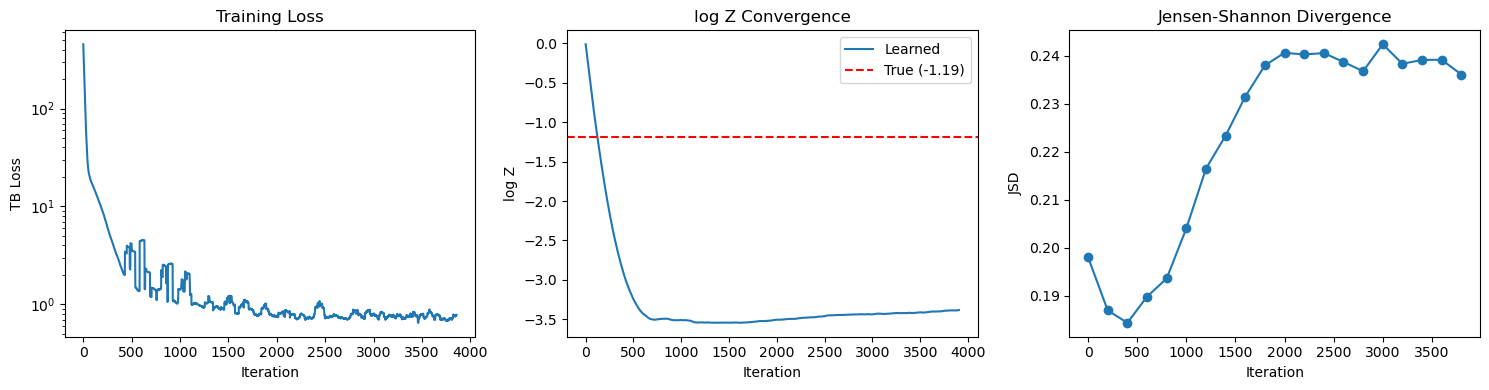

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve (smoothed).
window = 50
if len(loss_history) > window:
    smoothed = np.convolve(loss_history, np.ones(window) / window, mode="valid")
    axes[0].plot(smoothed)
else:
    axes[0].plot(loss_history)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("TB Loss")
axes[0].set_title("Training Loss")
axes[0].set_yscale("log")

# logZ convergence.
true_logZ = env.log_partition()
axes[1].plot(logZ_history, label="Learned")
axes[1].axhline(true_logZ, color="red", linestyle="--", label=f"True ({true_logZ:.2f})")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("log Z")
axes[1].set_title("log Z Convergence")
axes[1].legend()

# JSD over time.
if jsd_history:
    iters, jsds = zip(*jsd_history)
    axes[2].plot(iters, jsds, "o-")
    axes[2].set_xlabel("Iteration")
    axes[2].set_ylabel("JSD")
    axes[2].set_title("Jensen-Shannon Divergence")

plt.tight_layout()
plt.show()

## 7. Visualizing Results

Let's compare where the GFlowNet terminates versus the true reward distribution, and visualize the sampled trajectories.

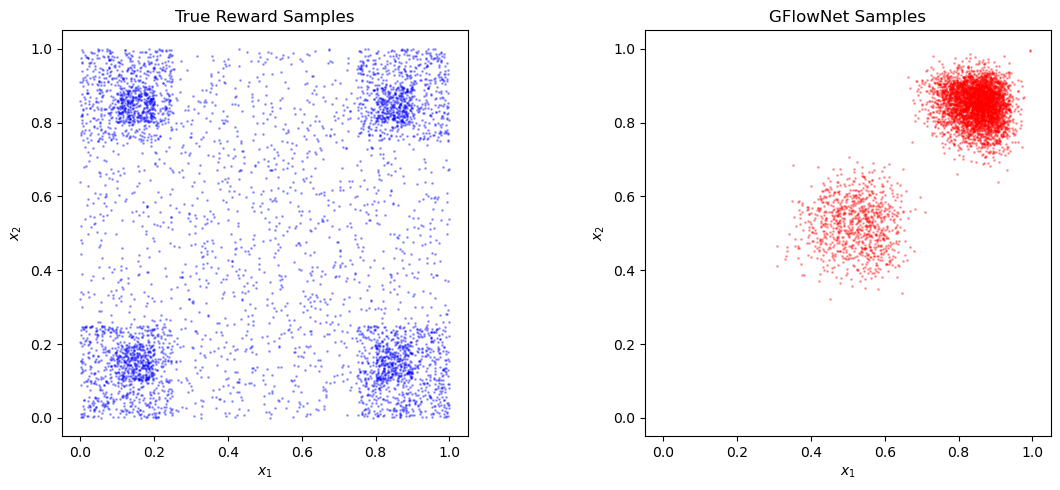

In [34]:
# Sample terminal states from the trained GFlowNet.
final_samples = gflownet.sample_terminating_states(env, 5000).tensor.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True reward samples.
axes[0].scatter(samples_from_reward[:5000, 0], samples_from_reward[:5000, 1],
                s=1, alpha=0.3, c="blue")
axes[0].set_title("True Reward Samples")
axes[0].set_xlim(-0.05, 1.05)
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_aspect("equal")

# GFlowNet samples.
axes[1].scatter(final_samples[:, 0], final_samples[:, 1],
                s=1, alpha=0.3, c="red")
axes[1].set_title("GFlowNet Samples")
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_aspect("equal")

for ax in axes:
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

plt.tight_layout()
plt.show()

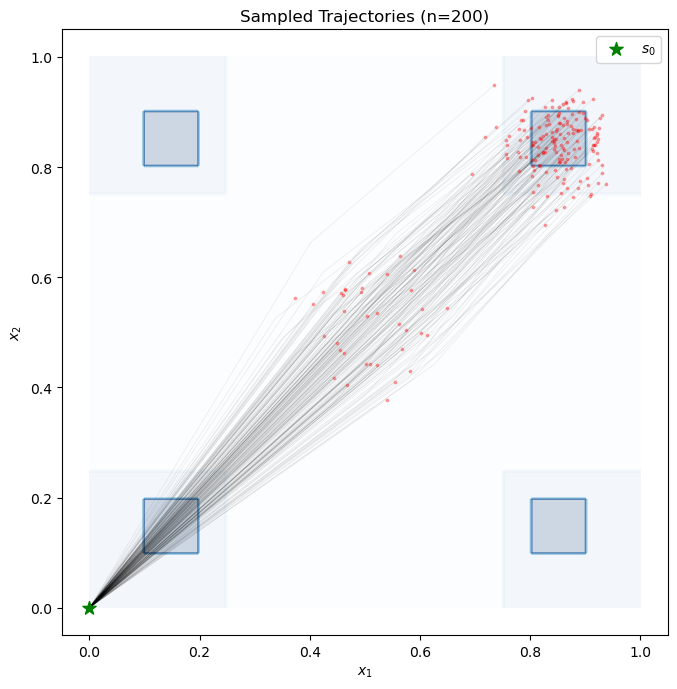

In [35]:
# Visualize trajectories: paths from s0 to terminal states.
n_traj_plot = 200
trajectories = sampler.sample_trajectories(env, n=n_traj_plot)
all_states = trajectories.states.tensor.cpu().numpy()
terminating_idx = trajectories.terminating_idx.cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 7))

# Reward contours in background.
ax.contourf(X, Y, rewards, levels=20, alpha=0.2, cmap="Blues")

for i in range(n_traj_plot):
    t = terminating_idx[i]
    traj = all_states[:t + 1, i, :]
    ax.plot(traj[:, 0], traj[:, 1], "k-", alpha=0.08, linewidth=0.5)
    # Terminal state.
    ax.scatter(traj[-2, 0], traj[-2, 1], c="red", s=3, alpha=0.3, zorder=5)

ax.scatter([0], [0], c="green", s=100, marker="*", zorder=10, label="$s_0$")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title(f"Sampled Trajectories (n={n_traj_plot})")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Diagnosing Mode Coverage

The reward landscape has four high-reward regions near the corners. Let's check how many modes the GFlowNet has actually discovered by counting samples in each quadrant.

In [36]:
def count_modes(samples: np.ndarray, env: Box, threshold: float = 0.01) -> dict:
    """Count samples in each reward mode region and report coverage.

    The reward is R0 + R1*(|x-0.5|>0.25 in both dims) + R2*(0.3<|x-0.5|<0.4 in both dims).
    The four modes are the four corners where |x_i - 0.5| > 0.25 for both dimensions.
    """
    n = len(samples)
    ax = np.abs(samples - 0.5)  # (n, 2)

    # Per-dimension: which side of 0.5?
    low_d = samples < 0.5  # shape (n, 2)
    in_reward = ax > 0.25   # in R1+ region per dim

    # A sample is "in a mode" if both dims are in the reward region.
    in_any_mode = in_reward[:, 0] & in_reward[:, 1]

    # Identify the four corners by sign of (x - 0.5) in each dim.
    modes = {
        "Bottom-Left  (low x1, low x2)":  low_d[:, 0] &  low_d[:, 1] & in_any_mode,
        "Bottom-Right (high x1, low x2)": ~low_d[:, 0] &  low_d[:, 1] & in_any_mode,
        "Top-Left     (low x1, high x2)":  low_d[:, 0] & ~low_d[:, 1] & in_any_mode,
        "Top-Right    (high x1, high x2)": ~low_d[:, 0] & ~low_d[:, 1] & in_any_mode,
    }

    # Also identify peak (R2) region: 0.3 < |x-0.5| < 0.4 in both dims.
    in_peak = ((0.3 < ax) & (ax < 0.4))
    in_peak_both = in_peak[:, 0] & in_peak[:, 1]

    results = {}
    print(f"  Reward thresholds: R0={env.R0}, R1={env.R1} (|x-0.5|>0.25), "
          f"R2={env.R2} (0.3<|x-0.5|<0.4)")
    print()
    for name, mask in modes.items():
        frac = mask.sum() / n
        peak_frac = (mask & in_peak_both).sum() / max(1, mask.sum())
        results[name] = frac
        status = "COVERED" if frac > threshold else "MISSING"
        print(f"  {name}: {frac:>6.1%}  [{status}]  (peak R2 region: {peak_frac:.0%})")

    covered = sum(1 for f in results.values() if f > threshold)
    outside = 1.0 - sum(results.values())
    print(f"\n  Modes covered: {covered}/4")
    print(f"  Samples outside reward modes: {outside:.1%}")
    return results

print("=== After initial training (500K trajectories, on-policy) ===")
mode_fracs = count_modes(final_samples, env)

=== After initial training (500K trajectories, on-policy) ===
  Reward thresholds: R0=0.1, R1=0.5 (|x-0.5|>0.25), R2=2.0 (0.3<|x-0.5|<0.4)

  Bottom-Left  (low x1, low x2):   0.0%  [MISSING]  (peak R2 region: 0%)
  Bottom-Right (high x1, low x2):   0.0%  [MISSING]  (peak R2 region: 0%)
  Top-Left     (low x1, high x2):   0.0%  [MISSING]  (peak R2 region: 0%)
  Top-Right    (high x1, high x2):  75.7%  [COVERED]  (peak R2 region: 51%)

  Modes covered: 1/4
  Samples outside reward modes: 24.3%


## 9. Improving Mode Coverage with Exploration

On-policy training often gets stuck covering only some modes because the policy
collapses early. Once the forward policy learns to reach one or two corners, it
rarely explores the others.

We can fix this by continuing training with **elevated temperature**. Setting
`temperature > 1` on the estimator flattens the exit/mixture-weight logits,
making the policy more exploratory. For continuous environments like the Box,
this is the natural exploration mechanism — epsilon-greedy doesn't apply because
there's no discrete action set to sample uniformly from.

Since the sampling temperature differs from 1.0 (the policy used in the TB
loss), the training data is **off-policy** and we must set
`recalculate_all_logprobs=True` so the loss uses the current T=1 policy's
probabilities rather than the stale cached ones.

We anneal the temperature back down to 1.0 over the course of training so the
model transitions from exploration to exploitation.

In [37]:
# Continue training with elevated temperature for exploration.
n_exploration_trajectories = int(5e5)  # Another 500K trajectories.
n_exploration_iters = n_exploration_trajectories // batch_size
temperature_explore = 2.5  # Higher temperature = flatter distributions = more exploration.

# Fresh optimizer with reset learning rates for the continuation phase.
optimizer_explore = torch.optim.Adam(pf_module.parameters(), lr=lr)
optimizer_explore.add_param_group({
    "params": pb_module.last_layer.parameters() if tied else pb_module.parameters(),
    "lr": lr,
})
optimizer_explore.add_param_group({"params": [logZ], "lr": lr_Z})

milestone_explore = max(1, n_exploration_iters // 3)
scheduler_explore = torch.optim.lr_scheduler.MultiStepLR(
    optimizer_explore,
    milestones=[i * milestone_explore for i in range(1, 4)],
    gamma=0.5,
)

# Continuation history.
loss_history_explore = []
logZ_history_explore = []
jsd_history_explore = []

for iteration in trange(n_exploration_iters, desc="Exploration training", dynamic_ncols=True):
    # Temperature annealing: decay from high temperature to 1.0 over training.
    anneal = min(1.0, iteration / max(1, n_exploration_iters))
    temperature = temperature_explore + anneal * (1.0 - temperature_explore)
    pf_estimator.temperature = temperature
    pb_estimator.temperature = temperature

    # Sample trajectories. Temperature > 1 makes this off-policy:
    # the sampling distribution differs from the T=1 policy used in the loss.
    trajectories = sampler.sample_trajectories(
        env, n=batch_size, save_logprobs=False,
    )

    optimizer_explore.zero_grad()
    # Must recalculate logprobs because sampling was off-policy (T != 1).
    loss = gflownet.loss_from_trajectories(
        env, trajectories, recalculate_all_logprobs=True,
    )
    loss.backward()

    for p in gflownet.parameters():
        if p.grad is not None:
            p.grad.data.clamp_(-10, 10).nan_to_num_(0.0)

    optimizer_explore.step()
    scheduler_explore.step()

    loss_history_explore.append(loss.item())
    logZ_history_explore.append(logZ.item())

    if iteration % validation_interval == 0:
        val_samples = gflownet.sample_terminating_states(env, n_validation)
        kde = KernelDensity(kernel="exponential", bandwidth=0.1).fit(
            val_samples.tensor.detach().cpu().numpy()
        )
        jsd = estimate_jsd(kde, true_kde)
        jsd_history_explore.append((iteration, jsd))

        true_logZ = env.log_partition()
        tqdm.write(
            f"  iter {iteration:>5d} | T {temperature:.2f} | loss {loss.item():.3f} | "
            f"logZ {logZ.item():.2f} (true {true_logZ:.2f}) | JSD {jsd:.4f}"
        )

print(f"\nDone. Final JSD after exploration: {jsd:.4f}")

Exploration training:   0%|          | 15/3906 [00:07<22:54,  2.83it/s] 

  iter     0 | T 2.50 | loss 1.004 | logZ -3.39 (true -1.19) | JSD 0.2002


Exploration training:   6%|▌         | 225/3906 [00:16<07:51,  7.80it/s] 

  iter   200 | T 2.42 | loss 0.908 | logZ -3.46 (true -1.19) | JSD 0.2058


Exploration training:  11%|█         | 419/3906 [00:25<06:58,  8.34it/s] 

...

  iter  3600 | T 1.12 | loss 0.592 | logZ -1.49 (true -1.19) | JSD 0.0021


Exploration training:  98%|█████████▊| 3825/3906 [02:52<00:07, 11.49it/s] 

  iter  3800 | T 1.04 | loss 0.590 | logZ -1.48 (true -1.19) | JSD 0.0020


Exploration training: 100%|██████████| 3906/3906 [02:52<00:00, 22.60it/s]


Done. Final JSD after exploration: 0.0020


## 10. Exploration Training Curves

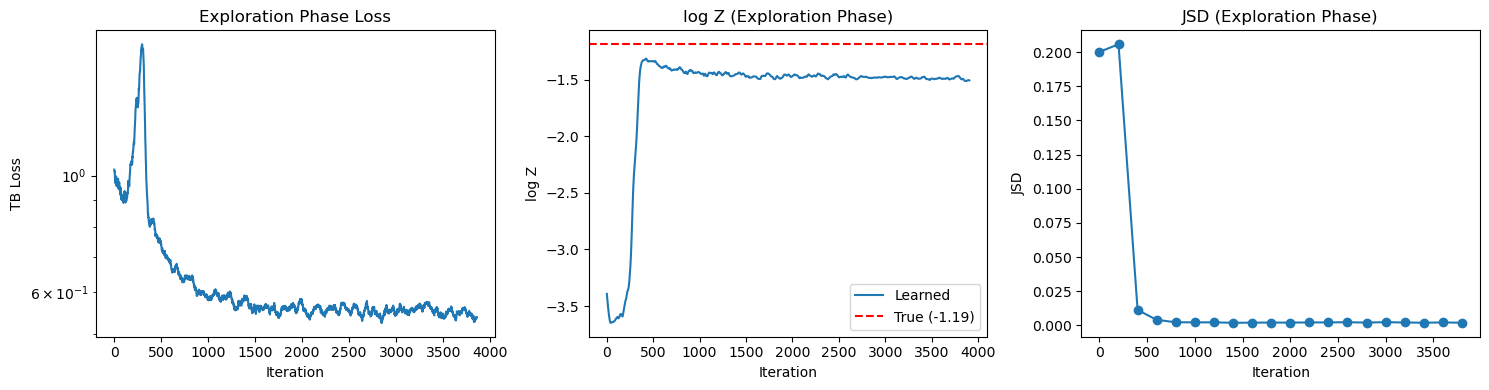

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve (smoothed).
if len(loss_history_explore) > window:
    smoothed = np.convolve(loss_history_explore, np.ones(window) / window, mode="valid")
    axes[0].plot(smoothed)
else:
    axes[0].plot(loss_history_explore)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("TB Loss")
axes[0].set_title("Exploration Phase Loss")
axes[0].set_yscale("log")

# logZ convergence.
axes[1].plot(logZ_history_explore, label="Learned")
axes[1].axhline(true_logZ, color="red", linestyle="--", label=f"True ({true_logZ:.2f})")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("log Z")
axes[1].set_title("log Z (Exploration Phase)")
axes[1].legend()

# JSD over time.
if jsd_history_explore:
    iters, jsds = zip(*jsd_history_explore)
    axes[2].plot(iters, jsds, "o-")
    axes[2].set_xlabel("Iteration")
    axes[2].set_ylabel("JSD")
    axes[2].set_title("JSD (Exploration Phase)")

plt.tight_layout()
plt.show()

## 11. Results After Exploration

Now let's compare the before/after: the initial on-policy samples alongside the
temperature-exploration-trained samples, and re-check mode coverage.

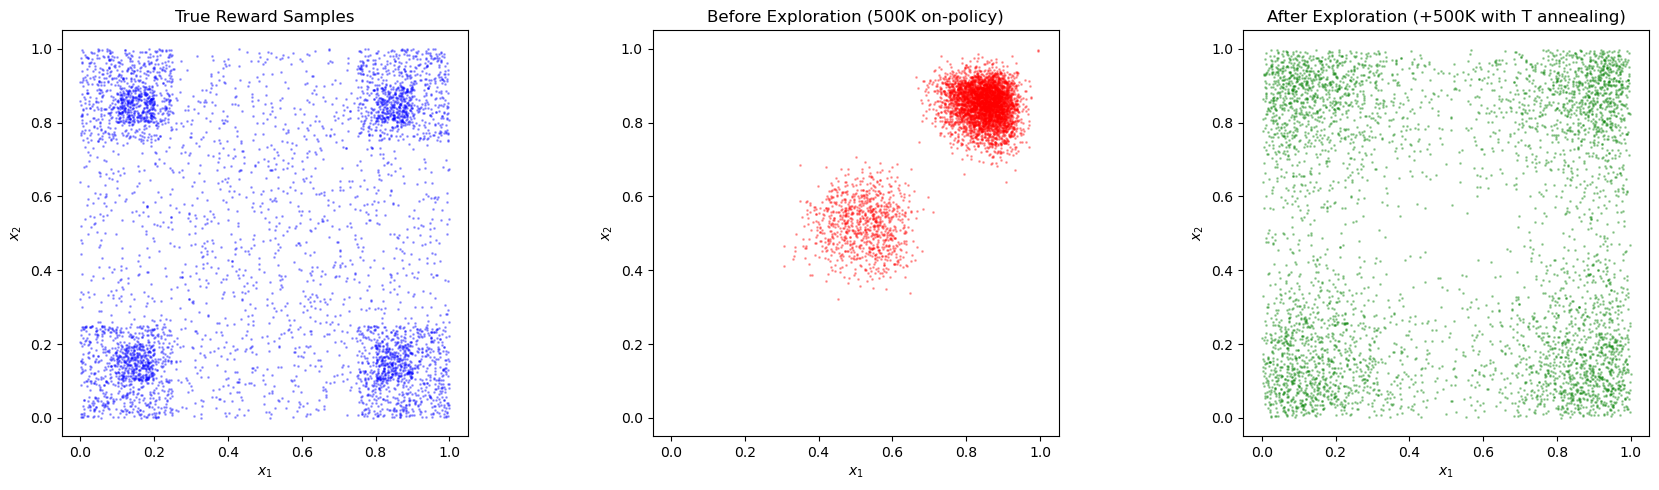

In [39]:
# Sample from the exploration-trained model (on-policy, no exploration noise).
pf_estimator.temperature = 1.0
pb_estimator.temperature = 1.0
explore_samples = gflownet.sample_terminating_states(env, 5000).tensor.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True reward samples.
axes[0].scatter(samples_from_reward[:5000, 0], samples_from_reward[:5000, 1],
                s=1, alpha=0.3, c="blue")
axes[0].set_title("True Reward Samples")

# Before exploration.
axes[1].scatter(final_samples[:, 0], final_samples[:, 1],
                s=1, alpha=0.3, c="red")
axes[1].set_title("Before Exploration (500K on-policy)")

# After exploration.
axes[2].scatter(explore_samples[:, 0], explore_samples[:, 1],
                s=1, alpha=0.3, c="green")
axes[2].set_title("After Exploration (+500K with T annealing)")

for ax in axes:
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect("equal")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

plt.tight_layout()
plt.show()

In [40]:
print("=== After exploration training (+500K with epsilon=0.1) ===")
explore_fracs = count_modes(explore_samples, env)

print("\n--- Comparison ---")
print(f"{'Mode':<35} {'Before':>8} {'After':>8}")
print("-" * 53)
for name in mode_fracs:
    b = mode_fracs[name]
    a = explore_fracs[name]
    arrow = "+" if a > b else ("-" if a < b else "=")
    print(f"{name:<35} {b:>7.1%} {a:>7.1%}  {arrow}")

=== After exploration training (+500K with epsilon=0.1) ===
  Reward thresholds: R0=0.1, R1=0.5 (|x-0.5|>0.25), R2=2.0 (0.3<|x-0.5|<0.4)

  Bottom-Left  (low x1, low x2):  14.1%  [COVERED]  (peak R2 region: 16%)
  Bottom-Right (high x1, low x2):  15.1%  [COVERED]  (peak R2 region: 17%)
  Top-Left     (low x1, high x2):  15.5%  [COVERED]  (peak R2 region: 16%)
  Top-Right    (high x1, high x2):  16.1%  [COVERED]  (peak R2 region: 17%)

  Modes covered: 4/4
  Samples outside reward modes: 39.2%

--- Comparison ---
Mode                                  Before    After
-----------------------------------------------------
Bottom-Left  (low x1, low x2)          0.0%   14.1%  +
Bottom-Right (high x1, low x2)         0.0%   15.1%  +
Top-Left     (low x1, high x2)         0.0%   15.5%  +
Top-Right    (high x1, high x2)       75.7%   16.1%  -


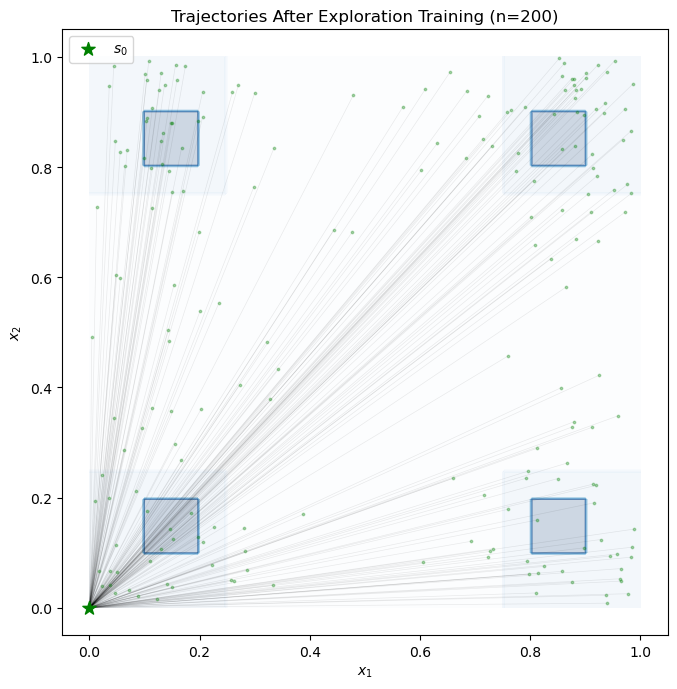

In [41]:
# Visualize trajectories after exploration training.
trajectories = sampler.sample_trajectories(env, n=n_traj_plot)
all_states = trajectories.states.tensor.cpu().numpy()
terminating_idx = trajectories.terminating_idx.cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 7))
ax.contourf(X, Y, rewards, levels=20, alpha=0.2, cmap="Blues")

for i in range(n_traj_plot):
    t = terminating_idx[i]
    traj = all_states[:t + 1, i, :]
    ax.plot(traj[:, 0], traj[:, 1], "k-", alpha=0.08, linewidth=0.5)
    ax.scatter(traj[-2, 0], traj[-2, 1], c="green", s=3, alpha=0.3, zorder=5)

ax.scatter([0], [0], c="green", s=100, marker="*", zorder=10, label="$s_0$")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title(f"Trajectories After Exploration Training (n={n_traj_plot})")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

**Mode collapse is a common failure mode** in continuous GFlowNets. The forward
policy can converge to a subset of modes before ever discovering the rest.

**Temperature annealing** is the natural exploration mechanism for continuous
environments. Setting `temperature > 1` on the estimator flattens the logits
for discrete decisions (exit probability, mixture weights), making the policy
explore more broadly. Epsilon-greedy, which mixes in uniform random actions,
is better suited to discrete environments where the action space is finite.

The key difference from on-policy training:

```python
# On-policy (T=1, can cache logprobs):
pf_estimator.temperature = 1.0
trajectories = sampler.sample_trajectories(env, n=N, save_logprobs=True)
loss = gflownet.loss_from_trajectories(env, traj, recalculate_all_logprobs=False)

# Off-policy (T>1, must recalculate):
pf_estimator.temperature = 2.5
trajectories = sampler.sample_trajectories(env, n=N, save_logprobs=False)
loss = gflownet.loss_from_trajectories(env, traj, recalculate_all_logprobs=True)
```

Other exploration strategies (replay buffers, local search) are covered in the
[Exploration Strategies](https://torchgfn.readthedocs.io/en/latest/guides/exploration_strategies.html) guide.